# Patient transfer adaptation through a crisis: The dynamics of a Hospitals Network during the COVID-19 pandemic.

**Autores:** Cicchini Tomás, Salgado Ariel, Otero Lisandro, Goldman Mariano, Yacobitti Alejandro, Doldan Victoria, Kochen Silvia, Boechi Leonardo, Caridi Inés.

_Instituto del Cálculo (UBA-CONICET), Hospital de Alta Complejidad en Red Nestor Carlos Kirchner, ENYS (CONICET-HEC-UNAJ), y desarrollador free-lance._


In [1]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import bases

import contextily as ctx
import osmnx as ox
from shapely.geometry import Point

import sys
import os
sys.path.append(os.path.abspath("../scripts"))
# nuestro módulo de funciones
import poster  # asegurate que bases.py esté en el mismo directorio

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cargar datos
print("Cargando datos principales...")
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
traslados = bases.reconstruir_traslados(df_pacientes)

# Filtrar por el período estudiado (2020/03/01 al 2022/12/15)
# Asegurarse de que la columna de fecha esté en formato datetime
if 'Fecha egreso' in traslados.columns:
    traslados['Fecha egreso'] = pd.to_datetime(traslados['Fecha egreso'])
    #traslados = traslados[(traslados['Fecha egreso'] >= '2020-01-01') & (traslados['Fecha egreso'] <= '2022-12-31')]

print(f"Traslados filtrados para el período: {len(traslados)} registros.")

# Geografia
print("Cargando datos geográficos...")
hosp_coords = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
municipios = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
municipios_amba = municipios[
    municipios["in1"].astype(str).str.startswith(("0"))
]
amba_partidos_caso = [
    "QUILMES", "ALMIRANTE BROWN",
    "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]
municipios_amba = municipios_amba[municipios_amba["nam_limpio"].isin(amba_partidos_caso)]

print("Datos geográficos cargados.")


Cargando datos principales...
Traslados filtrados para el período: 496 registros.
Cargando datos geográficos...
Datos geográficos cargados.


## The hospital network and the data.

**Contexto:** El trabajo en red permite optimizar recursos en momentos críticos.  
**Impacto COVID-19:** La pandemia puso en crisis a los sistemas de salud y obligó a adaptar infraestructuras.  
**Red Sudeste:** El sistema informático recolectó datos de camas y traslados de 14 hospitales de la Red Sudeste. Abarca cuatro municipios: Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE), cubriendo 661 km² y casi 2 millones de habitantes.


In [40]:
# Mapas (Paneles A, B y C)
# A. Aquí se visualiza la Provincia de Buenos Aires (PBA)

# ----------------------------
# cargar datos
# ----------------------------

paises = gpd.read_file("../data/ne_countries/ne_110m_admin_0_countries.shp")
provincias = gpd.read_file("../data/ne_provinces/ne_110m_admin_1_states_provinces.shp")

sudamerica = gpd.read_file("../data/ne_countries/ne_110m_admin_0_countries.shp")

In [42]:
# ----------------------------
# buscar cualquier referencia a "Buenos Aires" en provincias
# ----------------------------
import pandas as pd

# ----------------------------
# búsqueda exhaustiva de Buenos Aires (versión compatible con pandas 2+)
# ----------------------------
busqueda = "Buenos"

# recorrer todas las columnas de tipo string
for col in provincias.select_dtypes(include='string').columns:
    mask = provincias[col].str.contains(busqueda, case=False, na=False)
    resultados = provincias.loc[mask, [col, 'admin', 'geometry']]
    if not resultados.empty:
        print(f"--- columna: {col} ---")
        print(resultados)
        print()

resultados

,name_zht,admin,geometry


ValueError: aspect must be finite and positive 

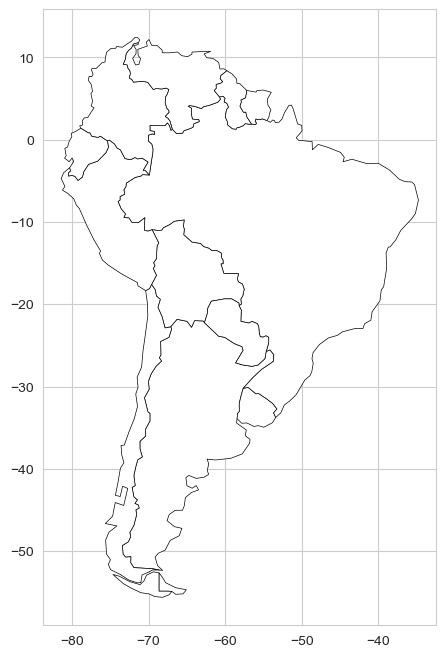

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt

# cargar shapefiles

# ----------------------------
# filtrar Sudamérica (en paises: ADMIN)
# ----------------------------
paises_sudamerica = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia",
    "Ecuador", "Guyana", "Paraguay", "Peru", "Suriname",
    "Uruguay", "Venezuela", "French Guiana"
]

sudamerica = paises[paises["ADMIN"].isin(paises_sudamerica)]

# ----------------------------
# filtrar provincia Buenos Aires (en provincias: name + admin)
# ----------------------------
pba = provincias[
    provincias["name"].str.contains("Buenos", case=False, na=False) &
    (provincias["admin"] == "Argentina")
]

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8,8))

# Sudamérica blanco con borde negro
sudamerica.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# Buenos Aires gris oscuro
pba.plot(ax=ax, color="dimgray", edgecolor="black", linewidth=0.8)

# centrar mapa
ax.set_xlim(-90, -30)
ax.set_ylim(-60, 15)

# sin ejes
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [28]:
print("Paises columns:", paises.columns)
print("Provincias columns:",provincias.columns)

Paises columns: Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)
Provincias columns: Index(['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2',
       'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt',
       ...
       'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT', 'FCLASS_NL',
       'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'FCLASS_TLC', 'geometry'],
      dtype='str', length=122)


In [25]:

# ----------------------------
# filtrar sudamerica
# ----------------------------

paises_sudamerica = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia",
    "Ecuador", "Guyana", "Paraguay", "Peru", "Suriname",
    "Uruguay", "Venezuela", "French Guiana"
]
sudamerica = sudamerica[sudamerica['name'].isin(paises_sudamerica)]




# ----------------------------
# filtrar provincia buenos aires
# ----------------------------
pba = provincias[(provincias['name'] == "Buenos Aires") & 
                 (provincias['admin'] == "Argentina")]

# crear figura
fig, ax = plt.subplots(figsize=(8, 8))

# plotear Sudamérica
sudamerica.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.6
)



# -----------------------
# provincia buenos aires
# -----------------------
pba.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.8
)

# centrar mapa
ax.set_xlim(-90, -30)
ax.set_ylim(-60, 15)

# quitar ejes
ax.axis("off")

# mostrar
plt.tight_layout()
plt.show()

KeyError: 'name'

In [ ]:



# B. La Red Sudeste


# C. Los asentamientos cercanos

Generando red general con filtro de al menos 4 traslados...
Registros luego de filtros: 496
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 11
Aristas en red: 23

Observaciones:
- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.
- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.


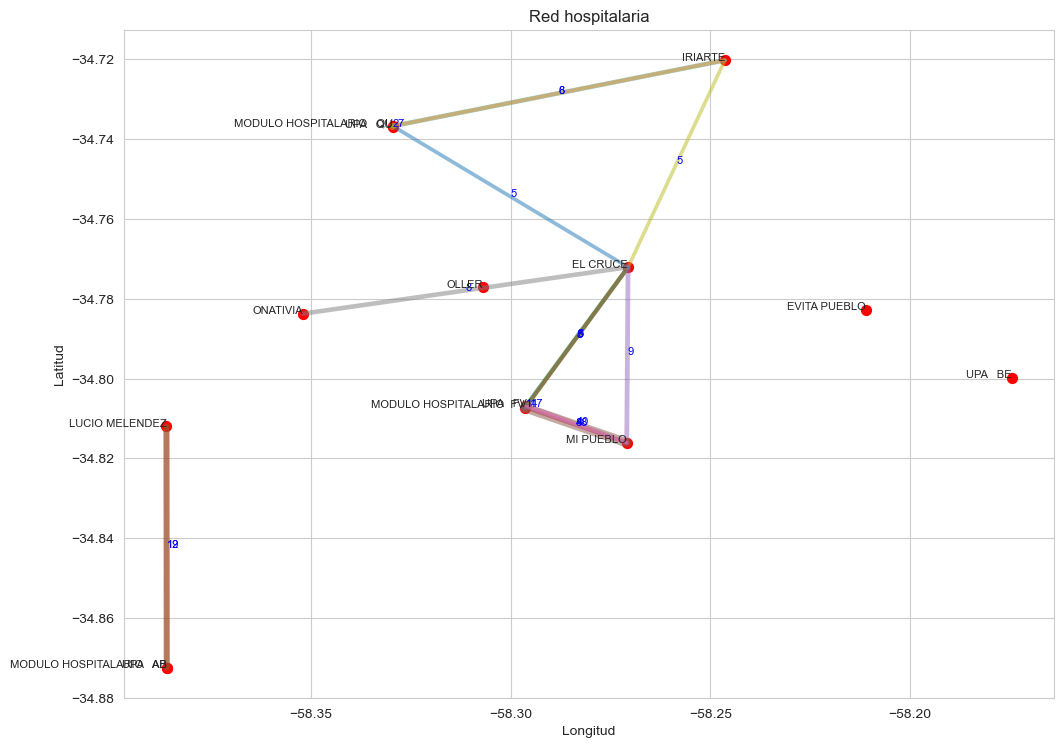

In [ ]:
# Red General (Panel D)
# Armar el grafo dirigido y pesado para todo el período
print("Generando red general con filtro de al menos 4 traslados...")
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=4, # Filtro aplicado
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=True
)

# Observaciones de la red
print("\nObservaciones:")
print("- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.")
print("- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.")

# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


In [ ]:
# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


## Inpatients Flow throughout Time.

Se divide el período en cuatro etapas: First Wave, Intermediate, Second Wave y Post Vaccination Stage. Existe concordancia entre la evolución de los ingresos y los traslados a lo largo del período.


In [13]:
# Gráfico de Series Temporales
# Gráfico de líneas con doble eje Y: "Admissions" (en rojo) y "Transfers" (en negro) desde abril de 2020 hasta diciembre de 2022.
# Sombras/líneas para delimitar el "National Lockdown" y las cuatro etapas mencionadas:
# 1. First Wave
# 2. Intermediate
# 3. Second Wave
# 4. Post Vaccination Stage


## Hospital Network: Evolution Throughout the Different Stages.

Se construyó una red separada para cada etapa pandémica y los nodos correspondientes a Módulos Hospitalarios y UPAs fueron separados.

**Hallazgos clave:**
- Los traslados UPA-Módulo aumentaron de la primera a la segunda ola, a pesar de que los ingresos y traslados totales fueron similares en ambas olas.
- Hubo una caída abrupta en la distancia total y mediana recorrida de la primera a la segunda ola, reflejando un aumento en la eficiencia de la red.
- En la etapa post-vacunación, se observó la esperada caída en el porcentaje de traslados sobre ingresos.


In [14]:
# Tabla Resumen por Etapas
import numpy as np

# Estructura inicial del DataFrame para recopilar las métricas de las 4 etapas
tabla_datos = {
    'Metric': [
        'Total days', 
        'Admissions', 
        'Total transfers (%)', 
        'Ambulance transfers (%)', 
        'N of total edges | N of ambulance edges', 
        'N of transfers by edge | N of ambulance transfers by edge', 
        'Total traveled distance / Median distance'
    ],
    'First Wave': [np.nan] * 7,
    'Intermediate': [np.nan] * 7,
    'Second Wave': [np.nan] * 7,
    'Post-Vaccination Stage': [np.nan] * 7
}

df_resumen = pd.DataFrame(tabla_datos)
df_resumen.set_index('Metric', inplace=True)

# Completar con la información a medida que se procesen las etapas
display(df_resumen)


,First Wave,Intermediate,Second Wave,Post-Vaccination Stage
Metric,,,,
Total days,NaN,NaN,NaN,NaN
Admissions,NaN,NaN,NaN,NaN
Total transfers (%),NaN,NaN,NaN,NaN
Ambulance transfers (%),NaN,NaN,NaN,NaN
N of total edges | N of ambulance edges,NaN,NaN,NaN,NaN
N of transfers by edge | N of ambulance transfers by edge,NaN,NaN,NaN,NaN
Total traveled distance / Median distance,NaN,NaN,NaN,NaN


In [15]:
# Sub-Grafos por Etapa
# Cuadrícula con 4 gráficos de red (una para cada etapa temporal)
# Tamaño de los nodos varían según la respectiva etapa para Oñativia, El Cruce, Mi Pueblo, etc.


## Inpatients Days and Topological Role / Source/Sink Role (SSR).

El rol topológico de cada hospital (Source/Sink Role) se calcula con la siguiente fórmula:

$$ssr_{i}=\frac{t_{i}^{in}-t_{i}^{out}}{t_{i}^{in}+t_{i}^{out}}$$

Donde $t_{i}^{in}$ y $t_{i}^{out}$ son los ingresos y egresos por traslados. Un valor de $ssr_{i}=1$ significa que el hospital es una fuente pura ("pure source"), mientras que $ssr_{j}=-1$ indica un sumidero puro ("pure sink").

**Clustering:** Al estudiar el SSR, surge un agrupamiento (clustering) debido a los diferentes niveles de complejidad de los hospitales.


In [16]:
# Cálculo y Visualización del SSR
# Aplicar la fórmula del SSR a los datos.
# Generar un gráfico (scatter plot o barras) mostrando el espectro de -1 a 1 para evidenciar clústers de complejidad.


## Bibliography

1. Alvarez et al.
2. Yacobitti et al.
3. [Instituto del Cálculo (UBA-CONICET)](https://ic.fcen.uba.ar/)
4. Kohler et al.
5. Rocha et al.
